In [8]:
%load_ext autoreload
%autoreload 2
import segmentation_models_pytorch as smp
import torch
from matplotlib import pyplot as plt
import numpy as np
from torchvision.io import read_image
import pytorch3d
from pytorch_lightning import LightningModule, Trainer
from constraints.visu.helpers import show_torch_image
from constraints.transforms import differentiable_rigid
from constraints.losses import CentroidLoss
from constraints.utils import rad2deg,deg2rad

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# try to overfit on one image and its mask
img = read_image("input.png")
mask = read_image("mask.png").float() / 255.0  # Normalize to [0, 1]
template = read_image("template.png").float() / 255.0  # Normalize to [0, 1]

print(mask.unique())
print(mask.shape)
mask_target = torch.zeros_like(mask[0], dtype=torch.long)  # Assuming the first channel contains the class labels
for c in range(mask.shape[0]):
    mask_target[mask[c] > 0] = c  # Assign class c where the mask is greater than 0
print(mask_target.unique())

tensor([0., 1.])
torch.Size([3, 256, 256])
tensor([0, 1, 2])


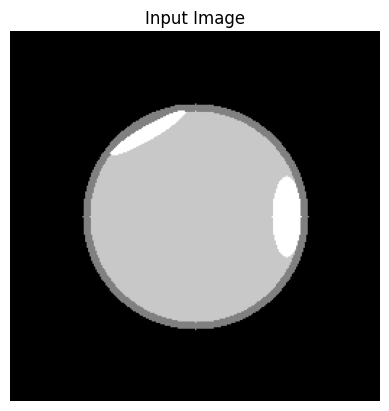

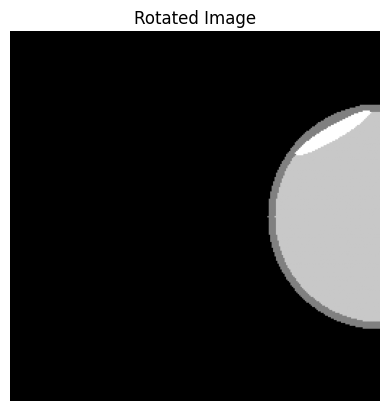

In [3]:
from constraints.transforms import differentiable_rigid
show_torch_image(img, title="Input Image",cmap="gray")
img.to(device="cpu")
show_torch_image(differentiable_rigid(img.float(), angle=0, dx=-1, dy=-0), title="Rotated Image",cmap="gray")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-51.195423..93.631134].


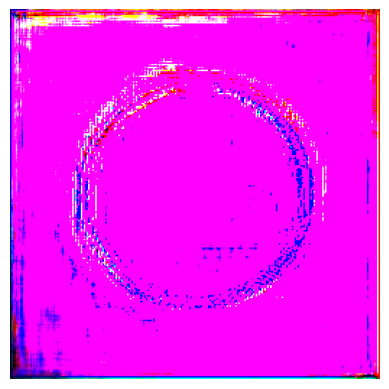

6
Layer 0: torch.Size([1, 1, 256, 256])
Layer 1: torch.Size([1, 64, 128, 128])
Layer 2: torch.Size([1, 64, 64, 64])
Layer 3: torch.Size([1, 128, 32, 32])
Layer 4: torch.Size([1, 256, 16, 16])
Layer 5: torch.Size([1, 512, 8, 8])


In [153]:
UNET = smp.Unet("resnet18", encoder_weights="imagenet", in_channels=1, classes=3)
# plainly test what happens
UNET.eval()
pred = UNET(img.unsqueeze(0).float())
show_torch_image(pred[0])
print(len(UNET.encoder(img.unsqueeze(0).float())))
for i, layer in enumerate(UNET.encoder(img.unsqueeze(0).float())):
    print(f"Layer {i}: {layer.shape}")


In [53]:
# # overfit only UNET branch
# UNET.train()
# optimizer = torch.optim.Adam(UNET.parameters(), lr=1e-3)
# criterion = torch.nn.CrossEntropyLoss()
# for epoch in range(100):
#     optimizer.zero_grad()
#     pred = UNET(img.unsqueeze(0).float())
#     loss = criterion(pred, mask_target.unsqueeze(0))
#     loss.backward()
#     optimizer.step()
#     if epoch % 10 == 0:
#         show_torch_image(torch.argmax(pred[0], dim=0))
#     print(f"Epoch {epoch}, Loss: {loss.item()}")

In [ ]:


def compute_chamfer_distance(pred_one_hot, gt_one_hot):
    # pred_one_hot and gt_one_hot shape: [B, C, H, W]
    device = pred_one_hot.device
    B, C, H, W = pred_one_hot.size()
    
    

In [122]:

converge_cnt = 0
for i in range(50):
    init = torch.randn(1) * deg2rad(30)
    angle = torch.nn.Parameter(torch.tensor([[init]]))
    opt = torch.optim.Adam([angle], lr=1e-2)
    for epoch in range(150):
        opt.zero_grad()
        rotated = differentiable_rotation(template.unsqueeze(0), angle)
        loss = torch.nn.functional.mse_loss(mask.float(), rotated)
        loss.backward()
        opt.step()

        # if epoch % 20 == 0:
        #     print(epoch, rad2deg(angle).item(), loss.item())
        
    if abs(rad2deg(angle).item() +10) < 0.1: #approx -10 degrees
        converge_cnt += 1
    
print("Converged for", converge_cnt, "out of 50 runs")

Converged for 46 out of 50 runs


In [ ]:


# create a two-branch module


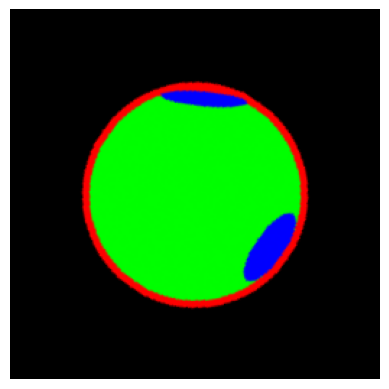

In [131]:
show_torch_image(differentiable_rotation(template.unsqueeze(0).float(), torch.tensor(-np.pi/4)))

In [155]:
from constraints.models.affine import TwoBranch

torch.manual_seed(22)
model = TwoBranch()
model.train()

# Materialize LazyConv2d parameters before creating the optimizer.
with torch.no_grad():
    model(img.unsqueeze(0).float())

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss1 = torch.nn.CrossEntropyLoss()
loss2 = CentroidLoss()

print("TASK:")
# show_torch_image(mask)
# show_torch_image(template)
print("RESULT:")
H,W = mask.shape[1], mask.shape[2]
for epoch in range(100):
    optimizer.zero_grad()
    decoded, angle, translation = model(img.unsqueeze(0).float())
    rotated_template = differentiable_rigid(template.float().unsqueeze(0), angle, dx=translation[:, 0], dy=translation[:, 1])
    print("angle:", rad2deg(angle).item())
    loss1_val = loss1(decoded, mask_target.unsqueeze(0))
    loss2_val =  100 * loss2(mask.float().unsqueeze(0), rotated_template.unsqueeze(0))
    loss = loss1_val + loss2_val
    loss.backward()
    
    optimizer.step()
    if epoch % 10 == 0:
        show_torch_image(torch.argmax(decoded[0], dim=0))
        show_torch_image(rotated_template)
        
    print(f"Epoch {epoch}, Losses: {loss1_val.item()} {loss2_val.item()}")

TASK:
RESULT:
angle: -171.1917266845703


/Users/michalmrkos/Documents/Skola/diplomka/ctu-constraints/constraints/losses.py:16: UserWarning: Using a target size (torch.Size([1, 1, 1, 1, 512])) that is different to the input size (torch.Size([1, 3, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  x_coords = (


RuntimeError: The size of tensor a (2) must match the size of tensor b (512) at non-singleton dimension 4

# With dataset

TASK:
RESULT:
angle: -55.9262809753418
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 0, Losses: 1.3038996458053589 2.2426917552948
angle: -146.79852294921875
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 1, Losses: 1.0585198402404785 4.426671028137207
angle: -140.51048278808594
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 2, Losses: 0.9026855826377869 1.0897223949432373
angle: -135.7652130126953
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 3, Losses: 0.7362566590309143 1.1723711490631104
angle: -133.50033569335938
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 4, Losses: 0.5915565490722656 0.8335305452346802
angle: -131.3179931640625
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 5, Losses: 0.5030893087387085 0.7939699292182922
angle: -129.22637939453125
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 6, Losses: 0.43729764223098755 0.6724480986595154
angle: -127.76154327392578
torch.S

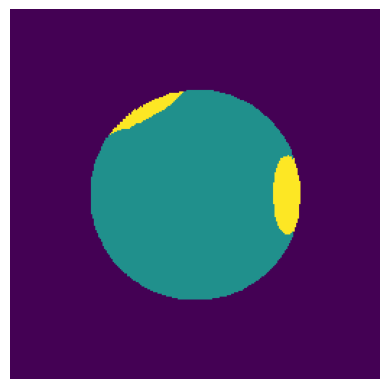

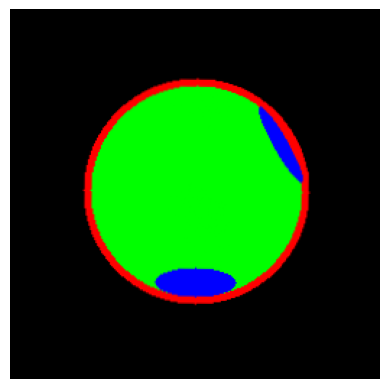

Epoch 49, Losses: 0.03777339309453964 0.0341411754488945
angle: -90.21852111816406
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 50, Losses: 0.036601852625608444 0.03743229806423187
angle: -89.81563568115234
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 51, Losses: 0.03547588735818863 0.03762108087539673
angle: -89.3819351196289
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 52, Losses: 0.034397512674331665 0.02441411465406418
angle: -88.95252227783203
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 53, Losses: 0.03337123990058899 0.03271771967411041
angle: -88.57295989990234
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 54, Losses: 0.03238297253847122 0.024084875360131264
angle: -88.23521423339844
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 55, Losses: 0.03145396709442139 0.02094119042158127
angle: -87.88998413085938
torch.Size([3, 256, 256]) torch.Size([1, 3, 256, 256])
Epoch 56, Losses: 0.030558

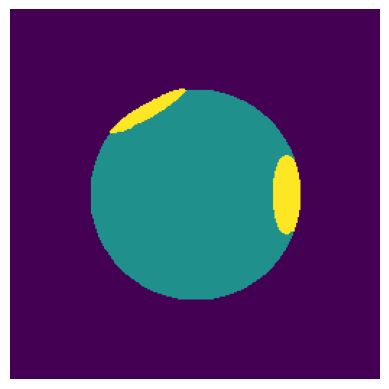

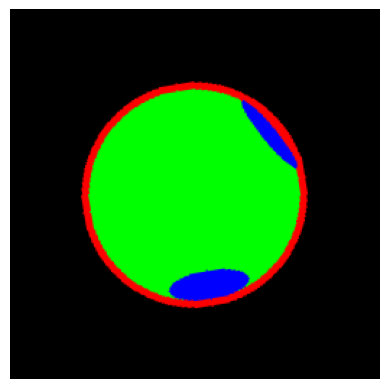

Epoch 99, Losses: 0.013923258520662785 0.00010836777073564008


In [17]:
from constraints.generators import AffineSampleBound, ArteryGeneratorAffine, ROT_ONLY
from constraints.models.affine import TwoBranch
from constraints.losses import CentroidLoss
trn_dataset = ArteryGeneratorAffine(fixed_seed=22,sample_specs=ROT_ONLY,num_samples=1000,speckle=0.1)
example = trn_dataset[1]
img = example['img']
mask = example['mask']
template = example['template']
model = TwoBranch()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss1 = torch.nn.CrossEntropyLoss()
loss2 = CentroidLoss()

print("TASK:")
# show_torch_image(mask)
# show_torch_image(template)
print("RESULT:")
H,W = mask.shape[1], mask.shape[2]
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    decoded, angle, translation = model(img.unsqueeze(0).float())
    rotated_template = differentiable_rigid(template.float().unsqueeze(0), angle, dx=translation[:, 0], dy=translation[:, 1])
    print("angle:", rad2deg(angle).item())
    loss1_val = loss1(decoded, mask_target.unsqueeze(0))
    print(mask.shape, rotated_template.shape)
    loss2_val =  100 * loss2(mask.float().unsqueeze(0), rotated_template.float())
    loss = loss1_val + loss2_val
    loss.backward()
    
    optimizer.step()
    if (epoch+1) % 50 == 0:
        show_torch_image(torch.argmax(decoded[0], dim=0))
        show_torch_image(rotated_template)
        
    print(f"Epoch {epoch}, Losses: {loss1_val.item()} {loss2_val.item()}")


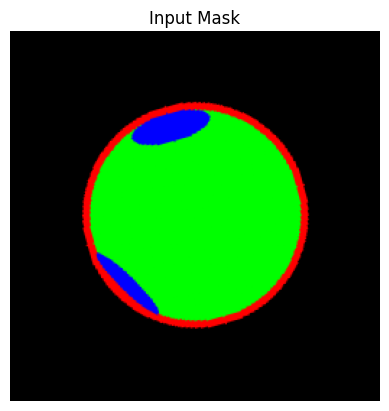

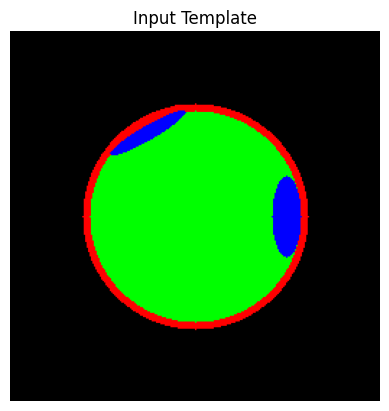

In [13]:
# show_torch_image(img, title="Input Image",cmap="gray")
show_torch_image(mask, title="Input Mask",cmap="gray")
show_torch_image(template, title="Input Template",cmap="gray")